In [ ]:
import torch
import numpy as np
import numpy.typing as npt
import pandas as pd
from pathlib import Path
import re
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# Add nibabel for loading NIfTI images (common medical imaging format)
try:
    import nibabel as nib
except ImportError:
    print("Warning: nibabel not installed. Install with: pip install nibabel")
    print("Or run: !pip install nibabel")
    nib = None

In [41]:
# input should be attention_weights from AggregateThenClassify forward output
def attcord_patch_map(
    att_tensor: torch.Tensor, # att_tensor[i] = attn_weight for token[i]
    coords: torch.Tensor,
    patch_grid_shape: tuple[int, int, int]  # Shape of patch grid (n_patches_d, n_patches_h, n_patches_w)
) -> npt.NDArray[np.float32]:
    """
    Create a patch-level attention map.
    
    Args:
        att_tensor: Attention weights [num_patches]
        coords: Patch coordinates [num_patches, 3] as (patch_d_idx, patch_h_idx, patch_w_idx)
        patch_grid_shape: Shape of the patch grid (max_d, max_h, max_w)
    
    Returns:
        Patch-level attention map [patch_grid_shape[0], patch_grid_shape[1], patch_grid_shape[2]]
    """
    patch_map = np.zeros(patch_grid_shape, dtype=np.float32)
    
    coords = np.asarray(coords, dtype=np.int64)
    att_tensor = att_tensor.detach().cpu().numpy().astype(np.float32)
    
    # Set attention weights at patch coordinates
    patch_map[coords[:,0], coords[:,1], coords[:,2]] = att_tensor
    
    return patch_map

def att_pixel_map( #call after calling attcord_patch_map
    patch_map: np.ndarray,
    patch_size: tuple[int, int, int] = (4, 16, 16) #size found from preprocess.py
) -> np.ndarray:
    """
    Expand patch-level attention map to voxel-level by repeating each patch.
    
    Args:
        patch_map: Patch attention map [n_patches_d, n_patches_h, n_patches_w]
        patch_size: Size of each patch (patch_d, patch_h, patch_w)
    
    Returns:
        Voxel attention map [n_patches_d * patch_d, n_patches_h * patch_h, n_patches_w * patch_w]
    """
    return patch_map.repeat(patch_size[0], axis=0).repeat(patch_size[1], axis=1).repeat(patch_size[2], axis=2)

# output of att_pixel map should look like attention per pixel
# this is a 3D voxel map where each voxel in a patch has the same attention weight
##########################################################  
# attn_weight(0,0) attn_weight(0,1) ... attn_weight(0,n) #
# attn_weight(1,0) attn_weight(1,1) ... attn_weight(1,n) #
# .                                                      #
# .                                                      #
# .                                                      #
# attn_weight(n,0) attn_weight(n,1) ... attn_weight(n,n) #

In [42]:
coords_path = "/Users/racheliritani/Desktop/neurovfm/attention inputs/val_coords"
coords_path = Path(coords_path)
attn_path = "/Users/racheliritani/Desktop/neurovfm/attention inputs/grid_classification_run_01"
attn_path = Path(attn_path)

coords_list = []
attn_list = []

coords_pattern = re.compile(r"^sub-(.+)_encoder_coords\.pt")
attn_pattern = re.compile(r"subject_(.+)_attention\.csv")

for file in coords_path.glob("*.pt"):
        match = coords_pattern.search(file.name)
        if match:
            subj_id = match.group(1)
            coords_tensor = torch.load(file, map_location="cpu", weights_only=True)
            coords_list.append(
                {
                    "subject id": subj_id,       
                    "coords": coords_tensor,
                }
            )

coords_df = pd.DataFrame(coords_list)


for file in attn_path.glob("*.csv"):
        match = attn_pattern.search(file.name)
        if match:
            subj_id = match.group(1)
            attn_tensor = pd.read_csv(file)
            attn_tensor = torch.tensor(attn_tensor["attention_weight"].values, dtype = torch.float32)
            
            attn_list.append(
                {
                    "subject id": subj_id,       
                    "attns": attn_tensor,
                }
            )

attn_df = pd.DataFrame(attn_list)

In [43]:
#attn_df.to_csv('/Users/racheliritani/Desktop/neurovfm/attention inputs/val_ids.csv')

In [44]:
def normalize_subject_id(s: str) -> str:
    s = str(s)

    # remove file-derived wrappers if present
    s = re.sub(r"_encoder_coords$", "", s)
    s = re.sub(r"_encoder_embeddings$", "", s)
    s = re.sub(r"_attention$", "", s)

    # remove leading subject_ or sub-
    s = re.sub(r"^subject_", "", s)
    s = re.sub(r"^sub-", "", s)

    return s

coords_df["merge_id"] = coords_df["subject id"].map(normalize_subject_id)
attn_df["merge_id"] = attn_df["subject id"].map(normalize_subject_id)

merged_df = coords_df.merge(
    attn_df,
    on="merge_id",
    how="inner",
    suffixes=("_coords", "_attn")
)

merged_df = merged_df.rename(columns={"merge_id": "subject_id"})
merged_df = merged_df.drop(columns=["subject id_coords", "subject id_attn"])

In [45]:
print("Merged data:")
print(merged_df.head())
print(f"\nTotal subjects: {len(merged_df)}")

# ===== LOAD ORIGINAL IMAGES =====
def load_original_image(subject_id: str, modality: str = "ct") -> np.ndarray:
    """
    Load the original preprocessed image for a subject.
    
    Args:
        subject_id: Subject identifier (e.g., '0001', 'sub-0001')
        modality: 'ct' or 'mri'
    
    Returns:
        3D numpy array of the original image
    """
    if nib is None:
        raise ImportError("nibabel is required to load NIfTI images. Install with: pip install nibabel")
    
    img_path = f'/Users/racheliritani/Desktop/neurovfm/attention inputs/val_mri/sub-{subject_id}_preproc-quasiraw_T1w.nii.gz'
    if Path(img_path).exists():
        nii_img = nib.load(img_path)
        return nii_img.get_fdata(dtype=np.float32)
    
    print(f"Warning: Could not find original image for subject {subject_id}")
    print(f"  Expected: {img_path}")
    return None

def load_images_for_subjects(merged_df: pd.DataFrame, modality: str = "ct") -> dict:
    """
    Load original images for all subjects in the merged dataframe.
    
    Args:
        merged_df: DataFrame with subject_id column
        modality: 'ct' or 'mri'
    
    Returns:
        Dictionary mapping subject_id to 3D image arrays
    """
    images = {}
    
    for subject_id in merged_df['subject_id'].unique():
        print(f"Loading image for subject {subject_id}...")
        img = load_original_image(subject_id, modality)
        if img is not None:
            images[subject_id] = img
            print(f"  Loaded image with shape: {img.shape}")
        else:
            print(f"  Failed to load image for subject {subject_id}")
    
    return images

subject_images = load_images_for_subjects(merged_df, modality="mri")
print(f"\nLoaded images for {len(subject_images)} subjects")

if len(subject_images) == 0:
    print("\nNo images were loaded. Please check:")
    print("1. Are your original images saved as .nii.gz files?")
    print("2. Are they in the expected directories?")
    print("3. Do the subject IDs match between your data and image files?")
else:
    print(f"\nSuccessfully loaded {len(subject_images)} images!")
    for i, (subject_id, img) in enumerate(list(subject_images.items())[:3]):
        print(f"  Subject {subject_id}: shape {img.shape}")


Merged data:
                                              coords    subject_id  \
0  [[tensor(0), tensor(0), tensor(0)], [tensor(0)...  104756934188   
1  [[tensor(0), tensor(0), tensor(0)], [tensor(0)...  103116472269   
2  [[tensor(0), tensor(0), tensor(0)], [tensor(0)...  104774505992   
3  [[tensor(0), tensor(0), tensor(0)], [tensor(0)...  100263562592   

                                               attns  
0  [tensor(0.0050), tensor(0.0035), tensor(0.0030...  
1  [tensor(0.0060), tensor(0.0041), tensor(0.0030...  
2  [tensor(0.0050), tensor(0.0039), tensor(0.0028...  
3  [tensor(0.0048), tensor(0.0035), tensor(0.0027...  

Total subjects: 4
Loading image for subject 104756934188...
  Loaded image with shape: (182, 218, 182)
Loading image for subject 103116472269...
  Loaded image with shape: (182, 218, 182)
Loading image for subject 104774505992...
  Loaded image with shape: (182, 218, 182)
Loading image for subject 100263562592...
  Loaded image with shape: (182, 218, 182)

L

In [46]:
print(f"merged_df shape: {merged_df.shape}")
print(f"Columns: {list(merged_df.columns)}")
print(f"Subject IDs: {merged_df['subject_id'].tolist()}")
print(f"Images loaded: {list(subject_images.keys())}")


merged_df shape: (4, 3)
Columns: ['coords', 'subject_id', 'attns']
Subject IDs: ['104756934188', '103116472269', '104774505992', '100263562592']
Images loaded: ['104756934188', '103116472269', '104774505992', '100263562592']


In [47]:
patch_size = (4, 16, 16)

def compute_attention_voxel_map(row):
    coords = row['coords']
    attns = row['attns']
    orig_img_shape = subject_images[row['subject_id']].shape

    # Derive patch grid shape from actual coordinate values
    if isinstance(coords, torch.Tensor):
        grid_max = coords.max(dim=0).values
    else:
        grid_max = np.asarray(coords, dtype=np.int64).max(axis=0)
    patch_grid_shape = tuple(int(v) + 1 for v in grid_max)

    # Build patch-level attention map and expand to voxel-level
    patch_map = attcord_patch_map(attns, coords, patch_grid_shape)
    voxel_map = att_pixel_map(patch_map, patch_size=patch_size)

    # Resize to original image dimensions (preprocessed != original resolution)
    zoom_factors = tuple(o / v for o, v in zip(orig_img_shape, voxel_map.shape))
    voxel_map = zoom(voxel_map, zoom_factors, order=1)

    return voxel_map

merged_df['attn_by_pixel'] = merged_df.apply(compute_attention_voxel_map, axis=1)
print(f"Computed attention voxel maps for {len(merged_df)} subjects")
print(f"Attention map shape: {merged_df.iloc[0]['attn_by_pixel'].shape}")
print(f"Original image shape: {subject_images[merged_df.iloc[0]['subject_id']].shape}")


Computed attention voxel maps for 4 subjects
Attention map shape: (182, 218, 182)
Original image shape: (182, 218, 182)


In [48]:
def normalize_map(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    xmin = np.nanmin(x)
    xmax = np.nanmax(x)
    if xmax > xmin:
        return (x - xmin) / (xmax - xmin)
    return np.zeros_like(x, dtype=np.float32)

In [49]:
def highlight_attention_on_3d_image(
    original_image: np.ndarray,
    attention_map: np.ndarray,
    threshold: float = 0.5,
    alpha: float = 0.7,
    colormap: str = "hot"
) -> np.ndarray:
    """
    Overlay attention heatmap on original 3D image.
    
    Args:
        original_image: Original 3D image [D, H, W]
        attention_map: Attention map [D, H, W] (same shape as original_image)
        threshold: Minimum attention weight to highlight (0-1)
        alpha: Transparency of overlay (0=invisible, 1=opaque)
        colormap: Matplotlib colormap name
    
    Returns:
        RGB visualization [D, H, W, 3] suitable for 3D viewers
    """
    import matplotlib.cm as cm
    
    # Normalize attention map
    attn_norm = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
    
    # Apply threshold
    attn_highlight = np.where(attn_norm >= threshold, attn_norm, 0)
    
    # Get colormap
    cmap = cm.get_cmap(colormap)
    attn_colored = cmap(attn_highlight)[:, :, :, :3]  # RGB, drop alpha
    
    # Normalize original image to [0,1]
    img_norm = (original_image - original_image.min()) / (original_image.max() - original_image.min() + 1e-8)
    img_rgb = np.stack([img_norm] * 3, axis=-1)  # Grayscale to RGB
    
    # Blend
    blended = (1 - alpha) * img_rgb + alpha * attn_colored
    
    return (blended * 255).astype(np.uint8)  # Convert to 0-255 range

# Example usage:
# highlighted_volume = highlight_attention_on_3d_image(
#     original_mri, 
#     attention_voxel_map, 
#     threshold=0.3, 
#     alpha=0.6
# )
# # Save as NIfTI or use in 3D viewer like ITK-SNAP

def normalize_map(x: np.ndarray) -> np.ndarray:
    """Normalize array to [0, 1] range."""
    x = x.astype(np.float32)
    xmin = np.nanmin(x)
    xmax = np.nanmax(x)
    if xmax > xmin:
        return (x - xmin) / (xmax - xmin)
    return np.zeros_like(x, dtype=np.float32)

In [50]:
# Working on overlaying attention on the slices
def overlay_attention_on_slice(
    mri_volume: np.ndarray,
    attn_voxel_map: np.ndarray,
    slice_idx: int,
    axis: int = 0,
    alpha: float = 0.4,
    threshold: float | None = None,
    cmap: str = "hot"
):
    if axis == 0:
        mri_slice = mri_volume[slice_idx, :, :]
        attn_slice = attn_voxel_map[slice_idx, :, :]
    elif axis == 1:
        mri_slice = mri_volume[:, slice_idx, :]
        attn_slice = attn_voxel_map[:, slice_idx, :]
    elif axis == 2:
        mri_slice = mri_volume[:, :, slice_idx]
        attn_slice = attn_voxel_map[:, :, slice_idx]
    else:
        raise ValueError("axis must be 0, 1, or 2")

    attn_slice = normalize_map(attn_slice)

    if threshold is not None:
        attn_slice = np.where(attn_slice >= threshold, attn_slice, np.nan)

    plt.figure(figsize=(6, 6))
    plt.imshow(mri_slice, cmap="gray")
    plt.imshow(attn_slice, cmap=cmap, alpha=alpha)
    plt.axis("off")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.show()

In [64]:
def visualize_attention_overlay(
    mri_volume: np.ndarray,
    attn_voxel_map: np.ndarray,
    slice_idx: int,
    axis: int = 0,
    alpha: float = 0.4,
    threshold: float = 0.0001,  # Only show attention above this normalized value
    cmap: str = "jet"
):
    """
    Overlays normalized attention on a specific slice of the 3D volume.
    """
    # 1. Extract the specific slice based on the chosen axis
    if axis == 0:
        img_slice = mri_volume[slice_idx, :, :]
        attn_slice = attn_voxel_map[slice_idx, :, :]
    elif axis == 1:
        img_slice = mri_volume[:, slice_idx, :]
        attn_slice = attn_voxel_map[:, slice_idx, :]
    else: # axis 2
        img_slice = mri_volume[:, :, slice_idx]
        attn_slice = attn_voxel_map[:, :, slice_idx]
        
    # 2. Normalize attention to [0, 1] for visualization
    # We use a small epsilon to avoid division by zero
    attn_norm = (attn_slice - np.nanmin(attn_slice)) / (np.nanmax(attn_slice) - np.nanmin(attn_slice) + 1e-8)

    # plt.hist(attn_norm.flatten(), bins=100)
    print(max(attn_norm.flatten()), min(attn_norm.flatten()))
    
    # # 3. Apply threshold
    attn_mask = np.where(attn_norm >= threshold, attn_norm, np.nan)
    
    # 4. Plot
    plt.figure(figsize=(8, 8))
    plt.imshow(img_slice, cmap="gray", origin="lower")
    plt.imshow(attn_mask, cmap=cmap, alpha=alpha, origin="lower", vmin=0, vmax=1)
    plt.colorbar(label='Normalized Attention')
    plt.title(f"Attention Overlay (Axis {axis}, Slice {slice_idx})")
    plt.axis("off")
    plt.show()

Visualizing slice 91 (middle of depth axis)
0.99999833 0.0


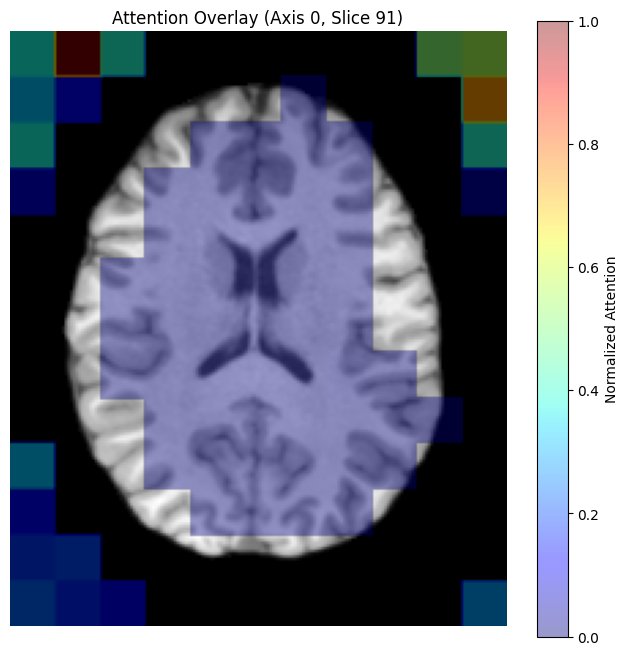

In [65]:
# Example usage:
subj_id = '104756934188'
row = merged_df.loc[merged_df['subject_id'] == subj_id].iloc[0]
# Use middle slice along each axis for best coverage
mid_slice = subject_images[subj_id].shape[0] // 2
print(f"Visualizing slice {mid_slice} (middle of depth axis)")
visualize_attention_overlay(subject_images[subj_id], row['attn_by_pixel'], mid_slice, axis=0)


0.9999985 0.0


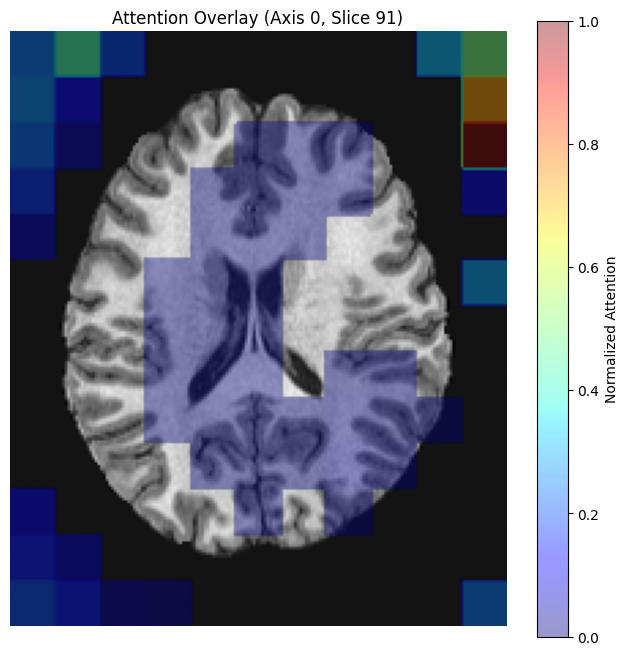

In [67]:
# Example usage:
subj_id = '103116472269'
row = merged_df.loc[merged_df['subject_id'] == subj_id].iloc[0]
visualize_attention_overlay(subject_images[subj_id], row['attn_by_pixel'], mid_slice, axis=0)

0.9999985 0.0


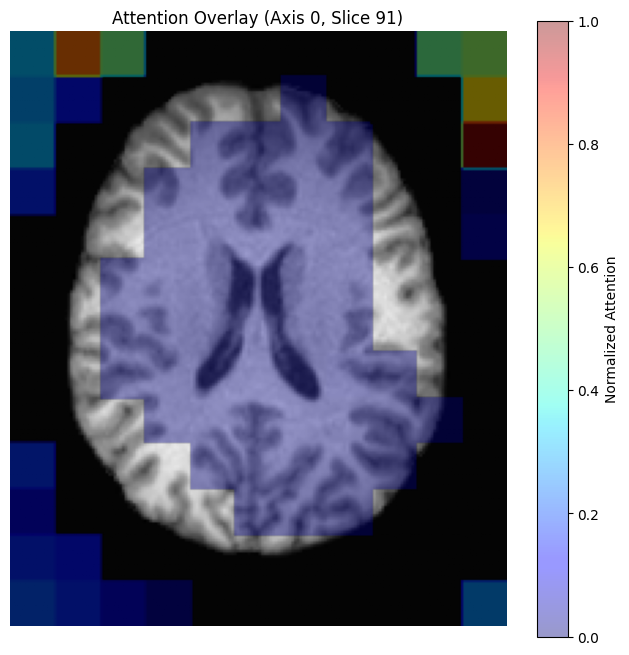

In [69]:
subj_id = '104774505992'
row = merged_df.loc[merged_df['subject_id'] == subj_id].iloc[0]
visualize_attention_overlay(subject_images[subj_id], row['attn_by_pixel'], mid_slice, axis=0)

0.99999833 0.0


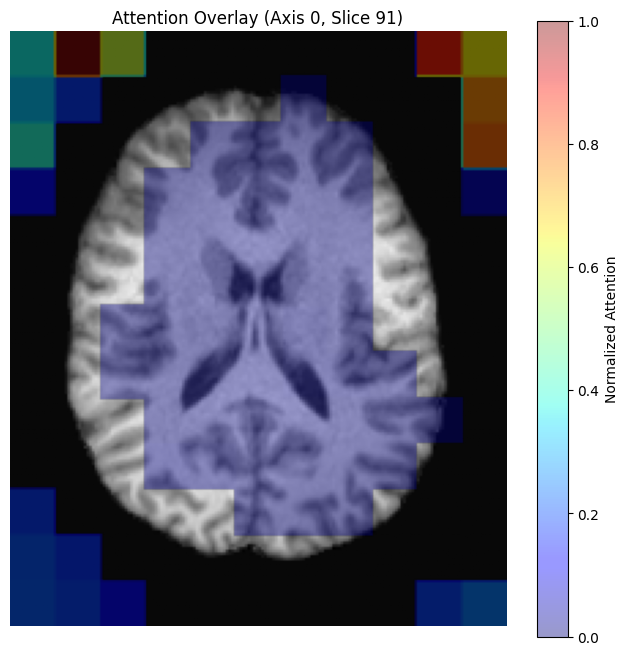

In [71]:
subj_id = '100263562592'
row = merged_df.loc[merged_df['subject_id'] == subj_id].iloc[0]
visualize_attention_overlay(subject_images[subj_id], row['attn_by_pixel'], mid_slice, axis=0)

In [72]:
# Save attention maps as NIfTI files for viewing in FSLeyes, ITK-SNAP, etc.
import os

output_dir = Path('attention_nifti_outputs')
output_dir.mkdir(exist_ok=True)

for _, row in merged_df.iterrows():
    subj = row['subject_id']
    attn_map = row['attn_by_pixel']

    # Re-load the NIfTI to get the affine and header
    img_path = f'/Users/racheliritani/Desktop/neurovfm/attention inputs/val_mri/sub-{subj}_preproc-quasiraw_T1w.nii.gz'
    ref_nii = nib.load(img_path)
    affine = ref_nii.affine
    header = ref_nii.header

    # Save the attention map (same geometry as original image)
    attn_nii = nib.Nifti1Image(attn_map.astype(np.float32), affine, header)
    attn_path = output_dir / f'sub-{subj}_attention.nii.gz'
    nib.save(attn_nii, str(attn_path))
    print(f'Saved: {attn_path}  (shape {attn_map.shape})')

print(f'\nDone! Open in your viewer of choice:')
print(f'  FSLeyes:  fsleyes <original.nii.gz> {output_dir}/<attention.nii.gz> -cm hot -a 50')
print(f'  ITK-SNAP: Load original as main image, attention as overlay')
print(f'  FreeView: freeview <original.nii.gz> {output_dir}/<attention.nii.gz>:colormap=heat:opacity=0.5')


Saved: attention_nifti_outputs/sub-104756934188_attention.nii.gz  (shape (182, 218, 182))
Saved: attention_nifti_outputs/sub-103116472269_attention.nii.gz  (shape (182, 218, 182))
Saved: attention_nifti_outputs/sub-104774505992_attention.nii.gz  (shape (182, 218, 182))
Saved: attention_nifti_outputs/sub-100263562592_attention.nii.gz  (shape (182, 218, 182))

Done! Open in your viewer of choice:
  FSLeyes:  fsleyes <original.nii.gz> attention_nifti_outputs/<attention.nii.gz> -cm hot -a 50
  ITK-SNAP: Load original as main image, attention as overlay
  FreeView: freeview <original.nii.gz> attention_nifti_outputs/<attention.nii.gz>:colormap=heat:opacity=0.5
